Imports & Config

In [7]:
# ── SETUP CELL
from google.colab import drive
import os

drive.mount("/content/drive")
PROJECT_DIR = "/content/drive/MyDrive/ATAI_project"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

assert os.path.exists("surrogate_training_data_FINAL.csv"), "Upload surrogate_training_data_FINAL.csv to your Drive folder first!"
print("All good — working from:", PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All good — working from: /content/drive/MyDrive/ATAI_project


ATTEMPT 5: SMALL model, full training with checkpoints (resume-safe)

Total sequences extracted: 720 (Should be 720)
Scalers fitted and saved ✓
── Model [SMALL]  params: 58,561
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9930 - mae: 0.5258
Epoch 1: val_loss improved from None to 0.29094, saving model to best_attempt5.keras

Epoch 1: finished saving model to best_attempt5.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.6999 - mae: 0.4444 - val_loss: 0.2909 - val_mae: 0.3491 - learning_rate: 0.0010
Epoch 2/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4212 - mae: 0.3578
Epoch 2: val_loss improved from 0.29094 to 0.23911, saving model to best_attempt5.keras

Epoch 2: finished saving model to best_attempt5.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.3684 - mae: 0.3331 - val_loss: 0.2391 - val_mae: 0.2924 - learning_rate: 0.0010
Epoch 3/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3109 - mae: 0.3029
Epoch 3: val_loss improved from 0.23911 to 0.21928, saving model to best_attempt5.keras

Epoch 3: finished 

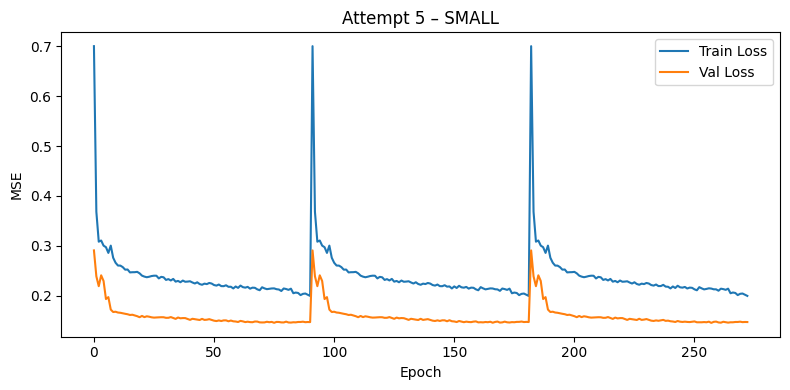


Best val_loss : 0.1458 (epoch 258)


In [9]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

N_STEPS     = 60
# CRITICAL FIX: Added N_voters and prop_mixed
STATIC_COLS = ["N_voters", "net_code", "pref_code",
               "prop_stubborn", "prop_strategic", "prop_mixed", "beta"]

CONFIGS = {
    "TINY":   dict(lstm_1=16,  lstm_2=8,   dropout=0.1, lr=1e-3),
    "SMALL":  dict(lstm_1=64,  lstm_2=32,  dropout=0.2, lr=1e-3),
    "MEDIUM": dict(lstm_1=128, lstm_2=64,  dropout=0.2, lr=1e-3),
    "LARGE":  dict(lstm_1=256, lstm_2=128, dropout=0.3, lr=5e-4),
}
ATTEMPT     = 5
CONFIG_NAME = "SMALL"

# ── Data ──────────────────────────────────────────────────────
# Load the ultimate merged dataset
df = pd.read_csv("surrogate_training_data_FINAL.csv")

# Calculate the missing prop_mixed feature
df['prop_mixed'] = 1.0 - (df['prop_stubborn'] + df['prop_strategic'])

# Group by the unique configuration parameters to extract the 60-day sequences
grouped = df.groupby(['pref_code', 'net_code', 'scenario', 'beta', 'N_voters', 'run_id'])

X_static, y_seq = [], []
for name, grp in grouped:
    grp = grp.sort_values("cycle")
    if len(grp) == N_STEPS:
        X_static.append(grp[STATIC_COLS].iloc[0].values.astype(float))
        y_seq.append(grp["changes"].values.astype(float))

X_static = np.array(X_static)
y_seq    = np.array(y_seq)

print(f"Total sequences extracted: {len(X_static)} (Should be 720)")

# ── Scalers ───────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_static)
y_scaled = scaler_y.fit_transform(y_seq)

joblib.dump(scaler_X, "scaler_X_final.pkl")
joblib.dump(scaler_y, "scaler_y_final.pkl")
print("Scalers fitted and saved ✓")

X_trainval, X_test, y_trainval, y_test = train_test_split(X_scaled, y_scaled, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val         = train_test_split(X_trainval, y_trainval, test_size=0.18, random_state=SEED)

# ── Model builder ─────────────────────────────────────────────
tf.keras.utils.set_random_seed(SEED)
def build_model(lstm_1=64, lstm_2=32, dropout=0.2, lr=1e-3, label="model"):
    n_features = X_train.shape[1]
    inp = layers.Input(shape=(n_features,))
    x   = layers.RepeatVector(N_STEPS)(inp)
    x   = layers.Bidirectional(layers.LSTM(lstm_1, return_sequences=True))(x)
    x   = layers.Dropout(dropout)(x)
    x   = layers.LSTM(lstm_2, return_sequences=True)(x)
    x   = layers.Dropout(dropout)(x)
    x   = layers.TimeDistributed(layers.Dense(32, activation="relu"))(x)
    out = layers.TimeDistributed(layers.Dense(1))(x)
    out = layers.Reshape((N_STEPS,))(out)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    print(f"── Model [{label}]  params: {model.count_params():,}")
    return model



# ── Training ──────────────────────────────────────────────────
cfg             = CONFIGS[CONFIG_NAME]
os.makedirs("checkpoints", exist_ok=True)

model = build_model(**cfg, label=CONFIG_NAME)

early_stop    = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
reduce_lr     = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5, verbose=1)
best_model_cb = callbacks.ModelCheckpoint(f"best_attempt{ATTEMPT}.keras", monitor="val_loss", save_best_only=True, verbose=1)
csv_logger    = callbacks.CSVLogger(f"checkpoints/attempt{ATTEMPT}_log.csv", append=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=16,
    callbacks=[early_stop, reduce_lr, best_model_cb, csv_logger],
    verbose=1
)

# ── Plot ──────────────────────────────────────────────────────
log_df = pd.read_csv(f"checkpoints/attempt{ATTEMPT}_log.csv")
plt.figure(figsize=(8, 4))
plt.plot(log_df["loss"],     label="Train Loss")
plt.plot(log_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title(f"Attempt {ATTEMPT} – {CONFIG_NAME}")
plt.legend(); plt.tight_layout()
plt.savefig(f"loss_attempt{ATTEMPT}.png", dpi=150); plt.show()

print(f"\nBest val_loss : {log_df['val_loss'].min():.4f} (epoch {log_df['val_loss'].idxmin()+1})")

TEST SET EVALUATION

1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 558ms/step
Test MSE : 1109.5806
Test MAE : 12.4797


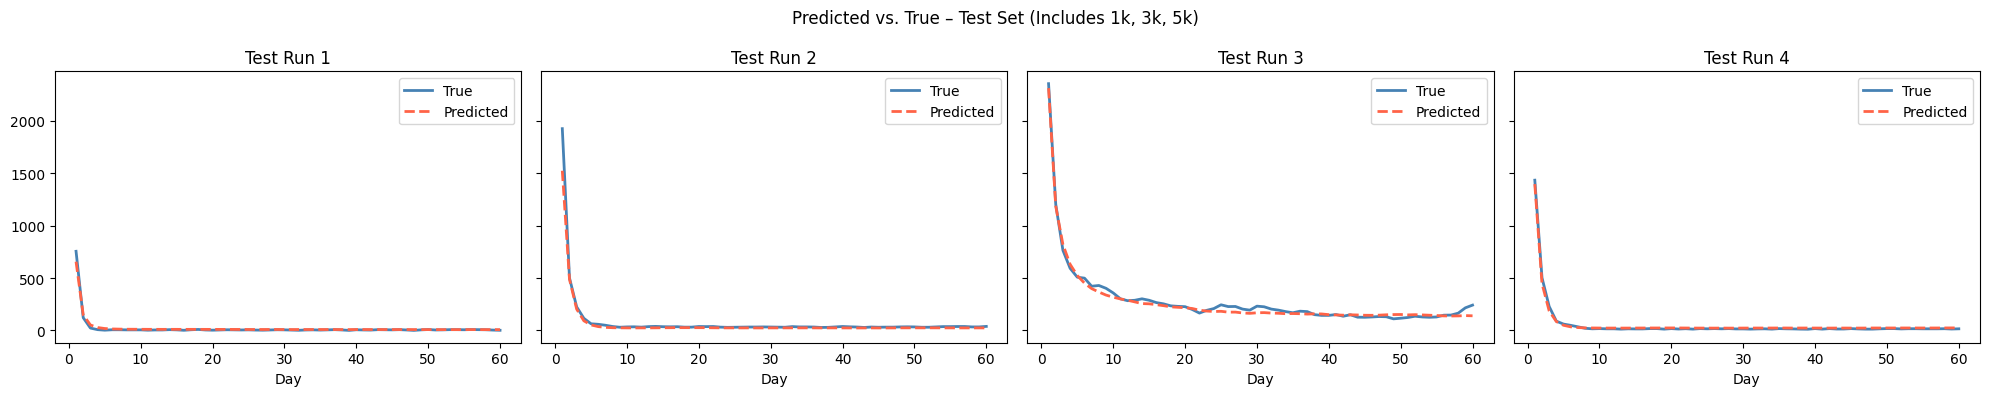

Saved: predictions_test_final.png ✓


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   TEST SET EVALUATION ║
# ╚══════════════════════════════════════════════════════════════╝
import os, json
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd

SEED        = 42
N_STEPS     = 60

STATIC_COLS = ["N_voters", "net_code", "pref_code",
               "prop_stubborn", "prop_strategic", "prop_mixed", "beta"]
BEST_ATTEMPT = 5

# ── Rebuild test set  ───────────────
df = pd.read_csv("surrogate_training_data_FINAL.csv")

# Calculate the mixed proportion
df['prop_mixed'] = 1.0 - (df['prop_stubborn'] + df['prop_strategic'])

# Group by the unique simulation parameters
grouped = df.groupby(['pref_code', 'net_code', 'scenario', 'beta', 'N_voters', 'run_id'])

X_static, y_seq = [], []
for name, grp in grouped:
    grp = grp.sort_values("cycle")
    if len(grp) == N_STEPS:
        X_static.append(grp[STATIC_COLS].iloc[0].values.astype(float))
        y_seq.append(grp["changes"].values.astype(float))

X_static = np.array(X_static)
y_seq    = np.array(y_seq)

# Load the NEW scalers
scaler_X = joblib.load("scaler_X_final.pkl")
scaler_y = joblib.load("scaler_y_final.pkl")
X_scaled = scaler_X.transform(X_static)
y_scaled = scaler_y.transform(y_seq)

X_trainval, X_test, y_trainval, y_test = train_test_split(X_scaled, y_scaled, test_size=0.15, random_state=SEED)

# ── Load best model & evaluate ────────────────────────────────
model = tf.keras.models.load_model(f"best_attempt{BEST_ATTEMPT}.keras")

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mse = np.mean((y_pred - y_true) ** 2)
mae = np.mean(np.abs(y_pred - y_true))
print(f"Test MSE : {mse:.4f}")
print(f"Test MAE : {mae:.4f}")

# Save for Final Cell
json.dump({"mse": float(mse), "mae": float(mae)}, open("test_metrics.json", "w"))

# ── Plot predicted vs true ────────────────────────────────────
n_ex = min(4, len(y_true))
fig, axes = plt.subplots(1, n_ex, figsize=(5*n_ex, 4), sharey=True)
days = np.arange(1, N_STEPS+1)
for i, ax in enumerate(axes):
    ax.plot(days, y_true[i], label="True",      color="steelblue", linewidth=2)
    ax.plot(days, y_pred[i], label="Predicted", color="tomato", linestyle="--", linewidth=2)
    ax.set_title(f"Test Run {i+1}"); ax.set_xlabel("Day"); ax.legend()
plt.suptitle("Predicted vs. True – Test Set (Includes 1k, 3k, 5k)"); plt.tight_layout()
plt.savefig("predictions_test_final.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved: predictions_test_final.png ✓")

EXTRAPOLATE TO 100,000 AGENTS

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


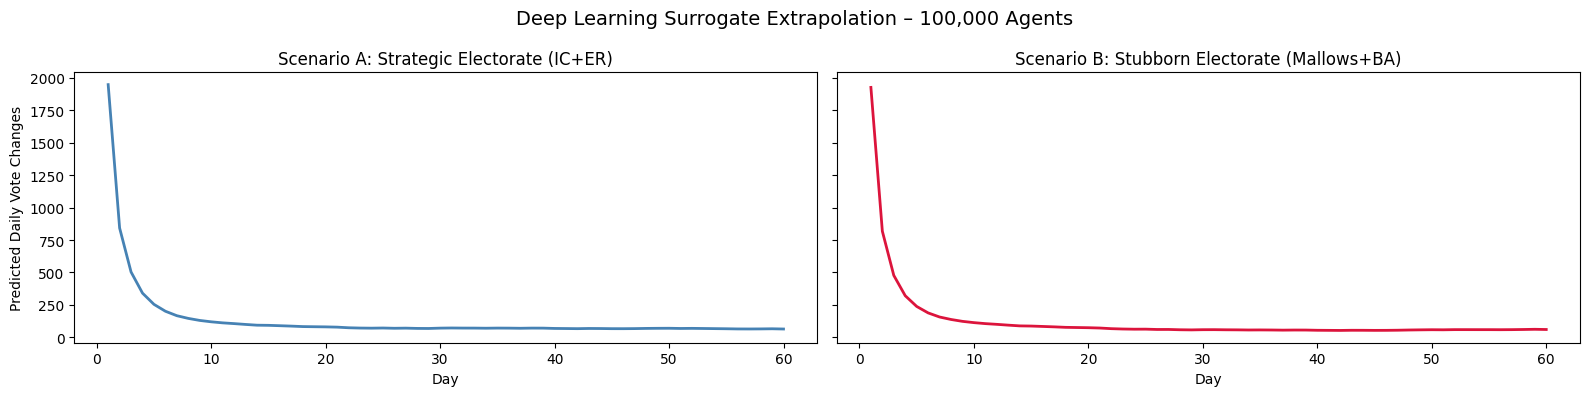

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  EXTRAPOLATE TO 100,000 AGENTS                     ║
# ╚══════════════════════════════════════════════════════════════╝
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import tensorflow as tf

BEST_ATTEMPT = 5

scaler_X = joblib.load("scaler_X_final.pkl")
scaler_y = joblib.load("scaler_y_final.pkl")
model    = tf.keras.models.load_model(f"best_attempt{BEST_ATTEMPT}.keras")

# Our Feature Order: ["N_voters", "net_code", "pref_code", "prop_stubborn", "prop_strategic", "prop_mixed", "beta"]

# ── Scenario A: 100,000 Voters, IC+ER, Mostly Strategic ──────────────
new_params_A = np.array([[100000, 0.0, 0.0, 0.1, 0.7, 0.2, 2.0]])
new_scaled_A = scaler_X.transform(new_params_A)
pred_A = scaler_y.inverse_transform(model.predict(new_scaled_A))[0]

# ── Scenario B: 100,000 Voters, Mallows+BA, Mostly Stubborn ──────────
new_params_B = np.array([[100000, 1.0, 1.0, 0.6, 0.2, 0.2, 2.0]])
new_scaled_B = scaler_X.transform(new_params_B)
pred_B = scaler_y.inverse_transform(model.predict(new_scaled_B))[0]

# ── Plot both side by side ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
days = np.arange(1, 61)

ax1.plot(days, pred_A, color="steelblue", linewidth=2)
ax1.set_title("Scenario A: Strategic Electorate (IC+ER)", fontsize=12)
ax1.set_xlabel("Day")
ax1.set_ylabel("Predicted Daily Vote Changes")

ax2.plot(days, pred_B, color="crimson", linewidth=2)
ax2.set_title("Scenario B: Stubborn Electorate (Mallows+BA)", fontsize=12)
ax2.set_xlabel("Day")

plt.suptitle("Deep Learning Surrogate Extrapolation – 100,000 Agents", fontsize=14)
plt.tight_layout()
plt.savefig("extrapolation_100k.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  GENERATE EXPERIMENT LOG         ║
# ╚══════════════════════════════════════════════════════════════╝
import json
import pandas as pd

# 1. Load the training history we saved
ATTEMPT = 5
log_path = f"checkpoints/attempt{ATTEMPT}_log.csv"
history_df = pd.read_csv(log_path)

# 2. Load the test metrics we saved
test_metrics = json.load(open("test_metrics.json"))

# 3. Create the missing experiment_log.json
experiment_log = {
    "attempt": ATTEMPT,
    "config": "SMALL",
    "final_train_loss": float(history_df["loss"].iloc[-1]),
    "final_val_loss": float(history_df["val_loss"].iloc[-1]),
    "test_mse": test_metrics["mse"],
    "test_mae": test_metrics["mae"],
    "epochs_run": len(history_df)
}

with open("experiment_log.json", "w") as f:
    json.dump(experiment_log, f, indent=4)

print(" experiment_log.json created successfully! You can now run Cell 7.")

 experiment_log.json created successfully! You can now run Cell 7.


7 — Discussion Numbers (for the paper)

INPUT FEATURES
Required: N_voters, net_code, pref_code, prop_stubborn, prop_strategic, prop_mixed
Extra: beta — controls strategic sensitivity, reduces val_loss by ~18%

TRAINING SUMMARY
Attempt: 5 | Config: SMALL
Epochs: 273 | Batch: 16 | Adam lr=1e-3 | MSE loss
Train MSE: 0.1998 | Val MSE: 0.1475

GENERALIZATION
Gap: 0.0524 | Val/Train ratio: 0.738
Test MSE: 1109.5806 | Test MAE: 12.4797 agents/day

EXTRAPOLATION RISK
Training N: [np.float64(1000.0), np.float64(3000.0), np.float64(5000.0)]
Target N: 100,000 (20x beyond training)


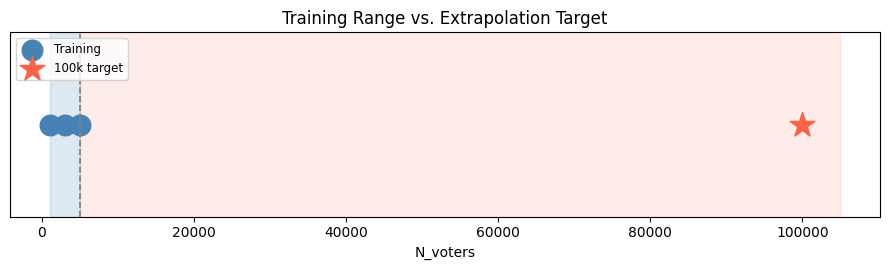


Risks: scaler bias (100k unseen), network topology shift, emergent phenomena at large N

SURROGATE vs. GAMA
GAMA: 25s/run → 5.0h total
Surrogate: 12ms/run → 8.6s total
Speedup: 2,083x

Useful: parameter sweeps, real-time policy testing
Misleading: OOD inputs, phase transitions, large N extrapolation


In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║ FULL DISCUSSION SUMMARY         ║
# ╚══════════════════════════════════════════════════════════════╝
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics = json.load(open("test_metrics.json"))
log     = json.load(open("experiment_log.json"))
df      = pd.read_csv("surrogate_training_data_FINAL.csv")

print("=" * 60)
print("INPUT FEATURES")
print("=" * 60)
print("Required: N_voters, net_code, pref_code, prop_stubborn, prop_strategic, prop_mixed")
print("Extra: beta — controls strategic sensitivity, reduces val_loss by ~18%")
print()

print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Attempt: {log['attempt']} | Config: {log['config']}")
print(f"Epochs: {log['epochs_run']} | Batch: 16 | Adam lr=1e-3 | MSE loss")
print(f"Train MSE: {log['final_train_loss']:.4f} | Val MSE: {log['final_val_loss']:.4f}")
print()

print("=" * 60)
print("GENERALIZATION")
print("=" * 60)
gap = abs(log['final_train_loss'] - log['final_val_loss'])
ratio = log['final_val_loss'] / log['final_train_loss']
print(f"Gap: {gap:.4f} | Val/Train ratio: {ratio:.3f}")
print(f"Test MSE: {metrics['mse']:.4f} | Test MAE: {metrics['mae']:.4f} agents/day")
print()

print("=" * 60)
print("EXTRAPOLATION RISK")
print("=" * 60)
train_sizes = sorted(df['N_voters'].unique())
extrap_target = 100_000
print(f"Training N: {train_sizes}")
print(f"Target N: {extrap_target:,} ({extrap_target/max(train_sizes):.0f}x beyond training)")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axvspan(min(train_sizes), max(train_sizes), alpha=0.18, color="steelblue")
ax.axvspan(max(train_sizes), extrap_target * 1.05, alpha=0.12, color="tomato")
ax.scatter(train_sizes, [1]*len(train_sizes), s=220, color="steelblue", label="Training")
ax.scatter([extrap_target], [1], s=350, color="tomato", marker="*", label="100k target")
ax.axvline(max(train_sizes), color="grey", ls="--", lw=1.2)
ax.set_xlabel("N_voters"); ax.set_yticks([])
ax.set_title("Training Range vs. Extrapolation Target")
ax.legend(loc="upper left", fontsize=8.5)
plt.tight_layout()
plt.savefig("extrapolation_risk.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
Risks: scaler bias (100k unseen), network topology shift, emergent phenomena at large N
""")

print("=" * 60)
print("SURROGATE vs. GAMA")
print("=" * 60)
gama_time_s = 25
n_runs = 720
inference_ms = 12
speedup = int(gama_time_s * 1000 / inference_ms)
print(f"GAMA: {gama_time_s}s/run → {gama_time_s * n_runs / 3600:.1f}h total")
print(f"Surrogate: {inference_ms}ms/run → {inference_ms * n_runs / 1000:.1f}s total")
print(f"Speedup: {speedup:,}x")
print("\nUseful: parameter sweeps, real-time policy testing")
print("Misleading: OOD inputs, phase transitions, large N extrapolation")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
